In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from tqdm import tqdm
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from scipy.stats import t
import matplotlib.pyplot as plt
import matplotlib
from sklearn.pipeline import Pipeline

from statsmodels.stats.sandwich_covariance import cov_hac #heteroscedasticity and autocorrelation robust covariance matrix (Newey-West)
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

In [ ]:
df_final = pd.read_excel("data/processed/df_final.xlsx")

In [ ]:
# Avant de normaliser > on regarde la dispersion de nos variables → on le commente dans notre recherche
summary_stats = df_final.describe().T[["mean", "std"]]

latex_table = summary_stats.to_latex(index=True, float_format="%.4f")
print(latex_table)

In [ ]:
df_final = df_final.sort_values("Date").reset_index(drop=True) 

In [ ]:
# Avant de normaliser > on regarde la dispersion de nos variables → on le commente dans notre recherche
summary_stats = df_final.describe().T[["mean", "std"]]
print(summary_stats.round(4))

Composition du notebook : 
I. Traitement des données (time split, gestion des NaN) et fonctions des métriques 
II. Algorithmes
III. Résultats

I. Traitement des données (time split, gestion des NaN) et fonctions des métriques 

In [ ]:
covariates = ["dolvol_lag2", "maxret", "retvol", "mom36m", "mom12m", "mom6m", "mom1m", "chmom", "turn", "indmom", "baspread", "illiq", "stdturn", "beta", "beta_squared",
"idiovol", "mvel1", "agr", "cashpr", "chinv", "chsh", "depr", "dy", "ep", "invest", "rd_mve", "sp", "nincr"]

In [ ]:
def generate_time_splits(df, date_col='Date',
                                   val_months=12,
                                   test_months=12,
                                   step_months=12,
                                   min_train_months=192):
    """
    Génère des splits temporels:
    - Train cumulatif (augmente d'un an à chaque refit)
    - Train 306 mois (= 85% de la data)
    - Validation = fenêtre fixe glissante de 1 an
    - Test = 1 an 
    - Avance de step_months à chaque itération : 1 an

    Paramètres :
    - df : DataFrame trié par date
    - date_col : nom de la colonne des dates
    - val_months : taille de la validation
    - test_months : taille du test 
    - step_months : pas de glissement
    - min_train_months : nombre minimum de mois de train initial

    Retour :
    - splits : liste de tuples (train_idx, val_idx, test_idx)
    """

    #On coupe chronologiquement donc on trie par date 
    df = df.sort_values(date_col).reset_index(drop=True)
    dates = sorted(df[date_col].unique())
    total_months = len(dates)

    splits = []

    #On démarre après avoir au moins min_train_months pour le train
    start = min_train_months
    while True:
        train_end = start  # train va de 0 jusqu'à train_end
        val_start = train_end
        val_end = val_start + val_months
        test_start = val_end
        test_end = test_start + test_months

        #Stop quand on a plus assez pour test
        if test_end > total_months:
            break

        train_dates = dates[:train_end]  
        val_dates = dates[val_start:val_end]
        test_dates = dates[test_start:test_end]

        train_idx = df[df[date_col].isin(train_dates)].index.tolist()
        val_idx = df[df[date_col].isin(val_dates)].index.tolist()
        test_idx = df[df[date_col].isin(test_dates)].index.tolist()

        splits.append((train_idx, val_idx, test_idx))

        #Décale fenêtre de un → on réactualise tous les 1 ans
        start += step_months

    return splits

In [ ]:
def preprocess_split(X_train, X_val, X_test, covariates):
    """
    Impute les NaN par moyenne par Ticker (fit sur train),
    puis normalise chaque covariable entre -1 et 1 par date (rang cross-sectionnel).

    Paramètres
    ----------
    X_train, X_val, X_test : DataFrames bruts (avec 'Ticker' et 'Date')
    covariates : liste des colonnes numériques à traiter

    Retour
    ------
    X_train_scaled, X_val_scaled, X_test_scaled : DataFrames transformés (covariates seulement)
    """
    #Gestion des NaN : moyenne par Ticker calculée sur le train
    means_by_ticker = x_train.groupby("Ticker")[covariates].mean(numeric_only=True)

    def fill_na_with_means(df):
        df = df.copy()
        for col in covariates:
            #On remplace NaN par la moyenne du ticker
            df[col] = df.apply(
                lambda row: means_by_ticker[col][row["Ticker"]] 
                            if pd.isna(row[col]) and row["Ticker"] in means_by_ticker.index 
                            else row[col],
                axis=1
            )
        return df

    x_train_imp = fill_na_with_means(x_train)
    x_val_imp   = fill_na_with_means(x_val)
    x_test_imp  = fill_na_with_means(x_test)

    #Normalisation cross-sectionnelle : par date
    def normalize_by_date(df):
        df = df.copy()
        out = pd.DataFrame(index=df.index, columns=covariates)
        for date_key, group_idx in df.groupby("Date").groups.items():
            sub = df.loc[group_idx, covariates]
            for cov in covariates:
                temp = sub[cov].dropna().sort_values()
                n = len(temp)
                if n == 1:
                    scores = pd.Series([0.0], index=temp.index)
                else:
                    scores = pd.Series(
                        2 * np.arange(n) / (n - 1) - 1, index=temp.index
                    )
                out.loc[temp.index, cov] = scores
        return out.astype(float)

    x_train_scaled = normalize_by_date(x_train_imp)
    x_val_scaled   = normalize_by_date(x_val_imp)
    x_test_scaled  = normalize_by_date(x_test_imp)

    #garde l'information de la date et du ticker
    x_train_scaled = pd.concat([x_train_imp[['Ticker','Date']].reset_index(drop=True), x_train_scaled.reset_index(drop=True)], axis=1)
    x_val_scaled   = pd.concat([x_val_imp[['Ticker','Date']].reset_index(drop=True), x_val_scaled.reset_index(drop=True)], axis=1)
    x_test_scaled  = pd.concat([x_test_imp[['Ticker','Date']].reset_index(drop=True), x_test_scaled.reset_index(drop=True)], axis=1)

    return x_train_scaled, x_val_scaled, x_test_scaled

In [ ]:
#Permet de récupérer x et y > on exclut notre variable cible y et on garder les covariates
def get_x_y(df, idx, target="excess_return"):
    subset = df.loc[idx].copy()
    x = subset.drop(columns=[target]) 
    y = subset[target]
    return x, y

In [ ]:
#On découpe les splits puis on applique la gestion des NaN et la normalisation définie plus haut
splits = generate_time_splits(df_final)

preprocessed_splits = []

for train_idx, val_idx, test_idx in tqdm(splits):
    x_train, y_train = get_x_y(df_final, train_idx)
    x_val, y_val = get_x_y(df_final, val_idx)
    x_test, y_test = get_x_y(df_final, test_idx)

    #Imputation + Normalisation
    x_train, x_val, x_test = preprocess_split(x_train, x_val, x_test, covariates) #on enlève ticker et date

    preprocessed_splits.append((x_train, y_train, x_val, y_val, x_test, y_test))

In [ ]:
"""Fonctions pour nos métriques : 
def r2: mesure le r2 selon la définition de Gu et al 
% ratio : success ratio, semblable à ce qui est fait dans le papier de Xiu et Liu
R2 benchmark : on compare le R2 de nos modèles à l'historical average 
"""

#Mesures : → peut être à tej 
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum(y_true**2) 
    return 1 - ss_res/ss_tot if ss_tot != 0 else np.nan

#% ratio:
def success_ratio(y_true, y_pred, ignore_zero=True):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    sign_true = np.sign(y_true)
    sign_pred = np.sign(y_pred)

    if ignore_zero:
        mask = sign_true != 0
        sign_true = sign_true[mask]
        sign_pred = sign_pred[mask]

    if len(sign_true) == 0:
        return np.nan  
    return (sign_true == sign_pred).mean()

#R2 benchmark 
def r2_vs_benchmark(y_true, y_pred_model, y_pred_bench):
    T = len(y_true)
    mspe_model = (1/T) * np.sum((y_true - y_pred_model)**2)
    mspe_bench = (1/T) * np.sum((y_true - y_pred_bench)**2)
    return 1 - (mspe_model / mspe_bench)

II. ALGORITHMES 
Pour chaque algo (HA, OLS, PLS, PCR, Enet, RF, GBRT, XGboost) on applique la même boucle d'entraînement, validation et test. Certains modèles étant particulièrement lents (RF et GBRT) on a décomposé le code en blocs distincts, un par modèle.  

Détails des listes: Chaque boucle produit les prédictions in-sample et out-of-sample, ainsi que les métriques associées. 

Listes communes à tous les modèles:
- y_true : vraies valeurs pour l'échantillon out-of-sample (test)
- y_trainval_true : vraies valeurs pour l’échantillon in-sample (train + val)
- dates_in, dates_oos: dates correspondantes aux observations in-sample et out-of-sample
- tickers_in, tickers_oos : pour l'instant, pas utilisé, pas utiles plus tard si on construit des portefeuilles

Ces listes sont initialisées une seule fois, dans le bloc du modèle de référence (Historical Average), et réutilisées dans tous les autres blocs.

Ensuite, pour chaque modèle, nous avons :
- y_trainval_pred_model : prédictions in-sample
- y_pred_model : prédictions oos
- r2_in_model : R² in sample, calculé par split 
- r2_oos_model : R² out-of-sample, calculé par split
- sucess_ratio_in_model et success_ratio_oos_model : utilisés pour calculer le success ratio 

Les résultats stockés dans ces listes sont ensuite utilisés dans la partie III. Résultats, pour l’analyse comparative des performances.

In [151]:
"""HISTORICAL AVERAGE"""

#Listes communes à tous les modèles
y_true = []
y_trainval_true = []
dates_in = []
dates_oos = []
tickers_in = []
tickers_oos = []
first_date_split = []

#Listes pour HA 
y_pred_ha = []
y_trainval_ha = []

r2_in_ha = []
r2_oos_ha = []

splits_oos = []
splits_in = []

success_ratio_in_ha = []
success_ratio_oos_ha = []

for split_idx, (x_train, y_train, x_val, y_val, x_test, y_test) in enumerate(preprocessed_splits, start=1):

    dates_split = x_test['Date'].unique()
    first_date_split.append(dates_split[0])

    #Entrainement du modèle
    #Concatène 
    tickers_trainval = pd.concat([x_train['Ticker'], x_val['Ticker']], ignore_index=True)
    dates_trainval = pd.concat([x_train['Date'], x_val['Date']], ignore_index=True)
    y_trainval_all = pd.concat([y_train, y_val], ignore_index=True)
    trainval = pd.DataFrame({'Ticker': tickers_trainval, 'y': y_trainval_all})

    #moyenne historique
    mean_by_ticker = trainval.groupby('Ticker')['y'].mean()
    preds_trainval = trainval['Ticker'].map(mean_by_ticker).values

    y_trainval_true.extend(trainval['y'])
    y_trainval_ha.extend(preds_trainval)
    dates_in.extend(dates_trainval)
    tickers_in.extend(tickers_trainval)

    r2_in = r2(trainval['y'], preds_trainval)
    sr_in = success_ratio(trainval['y'], preds_trainval)
    r2_in_ha.append(r2_in)
    success_ratio_in_ha.append(sr_in)

    # Out-of-sample
    preds_split = [mean_by_ticker.get(tkr, np.nan) for tkr in x_test['Ticker']]
    preds_split = np.array(preds_split)
    r2_out = r2(y_test, preds_split)
    sr_out = success_ratio(y_test, preds_split)

    r2_oos_ha.append(r2_out)
    success_ratio_oos_ha.append(sr_out)

    y_pred_ha.extend(preds_split)
    y_true.extend(y_test)
    dates_oos.extend(x_test['Date'])
    tickers_oos.extend(x_test['Ticker'])
    splits_oos.extend([split_idx] * len(x_test))
    splits_in.extend([split_idx] * len(trainval))

    print(f"[Split {split_idx}] R² HA IN-sample: {r2_in:.6f} | OOS: {r2_out:.6f} | SR IN: {sr_in:.3f} | SR OOS: {sr_out:.3f}")

# Conversion en array
y_trainval_true = np.array(y_trainval_true)
y_trainval_pred_ha = np.array(y_trainval_ha)

#général
dates_in = np.array(dates_in)
tickers_in = np.array(tickers_in)
dates_oos = np.array(dates_oos)
tickers_oos = np.array(tickers_oos)
y_true = np.array(y_true)
y_pred_ha = np.array(y_pred_ha)

splits_in = np.array(splits_in)


[Split 1] R² HA IN-sample: 0.022532 | OOS: -0.090013 | SR IN: 0.562 | SR OOS: 0.404
[Split 2] R² HA IN-sample: 0.014702 | OOS: 0.038366 | SR IN: 0.553 | SR OOS: 0.625
[Split 3] R² HA IN-sample: 0.017088 | OOS: 0.040437 | SR IN: 0.557 | SR OOS: 0.593
[Split 4] R² HA IN-sample: 0.018043 | OOS: -0.037014 | SR IN: 0.559 | SR OOS: 0.502
[Split 5] R² HA IN-sample: 0.016534 | OOS: 0.028351 | SR IN: 0.556 | SR OOS: 0.618
[Split 6] R² HA IN-sample: 0.016831 | OOS: 0.120348 | SR IN: 0.559 | SR OOS: 0.682
[Split 7] R² HA IN-sample: 0.018752 | OOS: 0.048575 | SR IN: 0.564 | SR OOS: 0.627
[Split 8] R² HA IN-sample: 0.019175 | OOS: -0.044497 | SR IN: 0.567 | SR OOS: 0.458
[Split 9] R² HA IN-sample: 0.018034 | OOS: 0.071978 | SR IN: 0.563 | SR OOS: 0.596
[Split 10] R² HA IN-sample: 0.019197 | OOS: 0.106359 | SR IN: 0.564 | SR OOS: 0.646
[Split 11] R² HA IN-sample: 0.020484 | OOS: -0.043278 | SR IN: 0.567 | SR OOS: 0.485
[Split 12] R² HA IN-sample: 0.018975 | OOS: 0.094262 | SR IN: 0.564 | SR OOS: 0.6

In [ ]:
"""
OLS : Ordinary Least Squares : Nous détaillons ici cet algorithme, la logique étant identique pour les autres modèles.
Listes utilisées : 
- r2_in_sample_list et r2_test_list : stockent, pour chaque split, les R² in‑sample et out‑of‑sample. Elles servent à analyser
  la performance split par split et à ajuster le tuning des modèles (utile pour les modèles à hyperparamètres).
- y_true : valeurs réelles de l’equity premium sur l’ensemble.
- y_pred_ols : prédictions correspondantes du modèle OLS. 
- y_trainval : données d’entraînement (train + validation) utilisées pour l’ajustement du modèle.
- dates_ols et tickers_ols : récupérées à chaque split pour pouvoir fusionner correctement les prédictions de tous les modèles
  et s’assurer que les lignes (dates/tickers) correspondent, évitant tout mélange potentiel des prédictions.

Df et résultats en sortie : 
- df_results_ols : df contenant les prédictions du modèles ols ainsi que la date et le ticker correspondant. 
- r2_results : dictionnaire contenant le r2 ols in sample et oos
"""

#Listes 
#stocke les r² par split + benchmark ha 
r2_in_ols = []
r2_oos_ols = []

#sucess ratio 
success_ratio_in_ols = []
success_ratio_oos_ols = []

#stocker les prédictions
y_trainval_ols = []
y_pred_ols = []
feature_importance_ols = []  #Stock les coefficients par split

for split_idx, (x_train, y_train, x_val, y_val, x_test, y_test) in enumerate(tqdm(preprocessed_splits), start=1):
    
    x_trainval = pd.concat([x_train[covariates], x_val[covariates]])
    y_trainval = pd.concat([y_train, y_val])

    #Entraînement du modèle
    ols = LinearRegression()
    ols.fit(x_trainval, y_trainval)

    coefs = np.abs(ols.coef_)
    
    #Prédictions 
    y_trainval_pred = ols.predict(x_trainval)
    y_test_pred = ols.predict(x_test[covariates])

    #R2 
    r2_in = r2(y_trainval, y_trainval_pred)
    r2_out = r2(y_test, y_test_pred)

    #Success ratio
    #à remplir !! !!! !! 
    
    #Stockage 
    y_pred_ols.append(y_test_pred)
    y_trainval_ols.append(y_trainval_pred) 
    feature_importance_ols.append(coefs)
    
    r2_in_ols.append(r2_in)
    r2_oos_ols.append(r2_out)

    print(f"Split {split_idx} | R² in-sample : {r2_in_ols[-1]:.6f} | R² oos : {r2_oos_ols[-1]:.6f}")

y_pred_ols = np.concatenate(y_pred_ols)
y_trainval_ols = np.concatenate(y_trainval_ols)


 42%|████▏     | 5/12 [00:00<00:00, 46.48it/s]

Split 1 | R² in-sample : 0.029090 | R² oos : -0.090978
Split 2 | R² in-sample : 0.020737 | R² oos : 0.063990
Split 3 | R² in-sample : 0.024779 | R² oos : 0.048169
Split 4 | R² in-sample : 0.025731 | R² oos : -0.056750
Split 5 | R² in-sample : 0.023524 | R² oos : 0.045697
Split 6 | R² in-sample : 0.024015 | R² oos : 0.115050
Split 7 | R² in-sample : 0.025707 | R² oos : 0.006292
Split 8 | R² in-sample : 0.025535 | R² oos : -0.050919
Split 9 | R² in-sample : 0.024174 | R² oos : 0.066669
Split 10 | R² in-sample : 0.025118 | R² oos : 0.094904


100%|██████████| 12/12 [00:00<00:00, 41.63it/s]

Split 11 | R² in-sample : 0.026158 | R² oos : -0.042614
Split 12 | R² in-sample : 0.024534 | R² oos : 0.086957


In [161]:
import numpy as np

mean_importance_ols = np.mean(feature_importance_ols, axis=0)
sorted_idx = np.argsort(mean_importance_ols)[::-1]
top_features_ols = [covariates[i] for i in sorted_idx[:15]]

print("Top 15 covariables OLS (par importance moyenne sur les splits) :")
for i in range(15):
    print(f"{top_features_ols[i]} → {mean_importance_ols[sorted_idx[i]]:.4f}")


Top 15 covariables OLS (par importance moyenne sur les splits) :
dy → 0.0080
chmom → 0.0080
mom36m → 0.0077
mom6m → 0.0058
turn → 0.0055
dolvol_lag2 → 0.0052
mvel1 → 0.0042
sp → 0.0040
rd_mve → 0.0039
agr → 0.0033
chinv → 0.0030
mom1m → 0.0029
illiq → 0.0028
maxret → 0.0027
retvol → 0.0026


In [163]:
"""
PLS : Partial Least Squares
Hyperparamètres :
- k : nombre de composantes latentes, choisi pour minimiser la MSE sur la validation.
"""

#Stocker les prédictions
y_trainval_pls = []
y_pred_pls = []
feature_importance_pls = [] 

#Stocker r2 par split
r2_in_pls = []
r2_oos_pls = []

# Success ratio
success_ratio_in_pls = []
success_ratio_oos_pls = []

# Hyperparamètres PLS
best_components_pls = []
mse_val_grids = []

for split_idx, (x_train, y_train, x_val, y_val, x_test, y_test) in enumerate(tqdm(preprocessed_splits), start=1):
    x_trainval = pd.concat([x_train[covariates], x_val[covariates]])
    y_trainval = pd.concat([y_train, y_val])

    candidate_ks = np.arange(1, 28)
    mse_val_grid = []
    best_mse = float('inf')
    best_k = None

    # Recherche du meilleur k
    for k in candidate_ks:
        pls = PLSRegression(n_components=k, scale=False)
        pls.fit(x_train[covariates], y_train)
        y_val_pred = pls.predict(x_val[covariates]).ravel()
        mse_val = mean_squared_error(y_val, y_val_pred)
        mse_val_grid.append(mse_val)

        if mse_val < best_mse:
            best_mse = mse_val
            best_k = k

    mse_val_grids.append(mse_val_grid)
    best_components_pls.append(best_k)
    print(f"Split {split_idx} : meilleur nombre de composantes k = {best_k}")

    # Réentraîner sur train+val avec le meilleur k + Test 
    pls_final = PLSRegression(n_components=best_k, scale=False)
    pls_final.fit(x_trainval, y_trainval)
    coefs = np.abs(pls.coef_.flatten())  #parfois un array 2D

    y_trainval_pred = pls_final.predict(x_trainval).ravel()
    y_test_pred = pls_final.predict(x_test[covariates]).ravel()

    #R2 
    r2_in = r2(y_trainval, y_trainval_pred)
    r2_out = r2(y_test, y_test_pred)

    # Success ratio
    sr_in = success_ratio(y_trainval.values, y_trainval_pred)
    sr_out = success_ratio(y_test, y_test_pred)

    # Stockage pour global
    y_pred_pls.append(y_test_pred)
    y_trainval_pls.append(y_trainval_pred)
    feature_importance_pls.append(coefs)

    r2_in_pls.append(r2_in)
    r2_oos_pls.append(r2_out)
    success_ratio_in_pls.append(sr_in)
    success_ratio_oos_pls.append(sr_out)
    
    print(f"R² in-sample : {r2_in:.6f} | R² oos : {r2_out:.6f}")

y_pred_pls = np.concatenate(y_pred_pls)
y_trainval_pls = np.concatenate(y_trainval_pls)

  8%|▊         | 1/12 [00:02<00:27,  2.51s/it]

Split 1 : meilleur nombre de composantes k = 1
R² in-sample : 0.023949 | R² oos : -0.092527


 17%|█▋        | 2/12 [00:05<00:29,  2.96s/it]

Split 2 : meilleur nombre de composantes k = 3
R² in-sample : 0.019731 | R² oos : 0.057948


 25%|██▌       | 3/12 [00:08<00:26,  2.98s/it]

...

Split 10 : meilleur nombre de composantes k = 1
R² in-sample : 0.021564 | R² oos : 0.104392


 92%|█████████▏| 11/12 [00:36<00:03,  3.97s/it]

Split 11 : meilleur nombre de composantes k = 1
R² in-sample : 0.022693 | R² oos : -0.041762


100%|██████████| 12/12 [00:41<00:00,  3.43s/it]

Split 12 : meilleur nombre de composantes k = 3
R² in-sample : 0.023913 | R² oos : 0.089704


In [169]:
"""
PCR : Principal Component Regression
Hyperparamètre : k (nombre de composantes principales)
"""

#Stocker les prédictions 
y_trainval_pcr = []
y_pred_pcr = []

# Stocke les R² par split
r2_in_pcr = []
r2_oos_pcr = []

# Success ratio
success_ratio_in_pcr = []
success_ratio_oos_pcr = []

# Hyperparamètres spécifiques PCR
best_components_pcr = []
mse_val_grids_pcr = []
feature_importance_pcr = []

for split_idx, (x_train, y_train, x_val, y_val, x_test, y_test) in enumerate(tqdm(preprocessed_splits), start=1):
    x_trainval = pd.concat([x_train[covariates], x_val[covariates]])
    y_trainval = pd.concat([y_train, y_val])

    candidate_ks = np.arange(1, 28)
    mse_val_grid = []
    best_mse = float('inf')
    best_k = None

    # Recherche du meilleur k
    for k in candidate_ks:
        pcr_pipe = Pipeline([
            ('pca', PCA(n_components=k)),
            ('reg', LinearRegression())
        ])
        pcr_pipe.fit(x_train[covariates], y_train)
        y_val_pred = pcr_pipe.predict(x_val[covariates]).ravel()
        mse_val = mean_squared_error(y_val, y_val_pred)
        mse_val_grid.append(mse_val)

        if mse_val < best_mse:
            best_mse = mse_val
            best_k = k

    mse_val_grids_pcr.append(mse_val_grid)
    best_components_pcr.append(best_k)
    print(f"Split {split_idx} : meilleur nombre de composantes k = {best_k}")

    # Réentraîner sur train+val avec le meilleur k + Test
    pcr_final = Pipeline([
        ('pca', PCA(n_components=best_k)),
        ('reg', LinearRegression())
    ])
    pcr_final.fit(x_trainval, y_trainval)
    
    coefs = np.abs(pcr_final.named_steps['reg'].coef_.flatten())
    y_trainval_pred = pcr_final.predict(x_trainval).ravel()
    y_test_pred = pcr_final.predict(x_test[covariates]).ravel()

    #R²
    r2_in = r2(y_trainval.values, y_trainval_pred)
    r2_out = r2(y_test, y_test_pred)

    # Success ratio
    sr_in = success_ratio(y_trainval.values, y_trainval_pred)
    sr_out = success_ratio(y_test, y_test_pred)
    
    # Stockage pour global
    y_pred_pcr.append(y_test_pred)
    y_trainval_pcr.append(y_trainval_pred)
    feature_importance_pcr.append(coefs)
    
    r2_in_pcr.append(r2_in)
    r2_oos_pcr.append(r2_out)
    success_ratio_in_pcr.append(sr_in)
    success_ratio_oos_pcr.append(sr_out)

    print(f"R² in-sample : {r2_in:.6f} | R² oos : {r2_out:.6f}")

# Concaténation des résultats
y_pred_pcr = np.concatenate(y_pred_pcr)
y_trainval_pcr = np.concatenate(y_trainval_pcr)

  8%|▊         | 1/12 [00:00<00:04,  2.71it/s]

Split 1 : meilleur nombre de composantes k = 1
R² in-sample : 0.021485 | R² oos : -0.090568


 17%|█▋        | 2/12 [00:00<00:04,  2.50it/s]

Split 2 : meilleur nombre de composantes k = 9
R² in-sample : 0.016940 | R² oos : 0.054442


 25%|██▌       | 3/12 [00:01<00:03,  2.45it/s]

...

Split 10 : meilleur nombre de composantes k = 3
R² in-sample : 0.019767 | R² oos : 0.105657


 92%|█████████▏| 11/12 [00:05<00:00,  1.89it/s]

Split 11 : meilleur nombre de composantes k = 4
R² in-sample : 0.021170 | R² oos : -0.048756


100%|██████████| 12/12 [00:05<00:00,  2.12it/s]

Split 12 : meilleur nombre de composantes k = 7
R² in-sample : 0.021827 | R² oos : 0.090992


In [170]:
"""
ENet : Elastic Net
Hyperparamètres :
- lambda (alpha) : coefficient de pénalisation choisi pour minimiser la MSE
- l1_ratio fixé à 0.5
"""

#Prédictions 
y_pred_en = []
y_trainval_en = []

#R² par split
r2_in_en = []
r2_oos_en = []

# Success ratio
success_ratio_in_en = []
success_ratio_oos_en = []

# Hyperparamètres spécifiques
best_lambdas = []
nonzero_counts_en = []
feature_importance_en = []

enet_param_grid = {
    'alpha': np.logspace(-4, 0, num=10)
}

for split_idx, (x_train, y_train, x_val, y_val, x_test, y_test) in enumerate(tqdm(preprocessed_splits), start=1):
    best_mse = float('inf')
    best_lambda = None

    # Recherche du meilleur alpha
    for params in ParameterGrid(enet_param_grid):
        enet = ElasticNet(**params, l1_ratio=0.5, max_iter=10000)
        enet.fit(x_train[covariates], y_train)
        y_val_pred = enet.predict(x_val[covariates])
        mse = mean_squared_error(y_val, y_val_pred)
        if mse < best_mse:
            best_mse = mse
            best_lambda = params['alpha']

    best_lambdas.append(best_lambda)
    print(f"Split {split_idx} : meilleur lambda = {best_lambda}")

    #Entrainement + Test 
    x_trainval = pd.concat([x_train[covariates], x_val[covariates]])
    y_trainval = pd.concat([y_train, y_val])
    en_final = ElasticNet(alpha=best_lambda, l1_ratio=0.5, max_iter=10000)
    en_final.fit(x_trainval, y_trainval)

    coefs = np.abs(en_final.coef_)

    y_trainval_pred = en_final.predict(x_trainval)
    y_test_pred = en_final.predict(x_test[covariates])
    
    # Calcul du nombre de coefficients non nuls
    nonzero_count = np.sum(en_final.coef_ != 0)
    nonzero_counts_en.append(nonzero_count)

    # R² 
    r2_in = r2(y_trainval.values, y_trainval_pred)
    r2_out = r2(y_test, y_test_pred)
    
    # Success ratio
    sr_in = success_ratio(y_trainval.values, y_trainval_pred)
    sr_out = success_ratio(y_test, y_test_pred)

    # Stockage 
    y_pred_en.append(y_test_pred)
    y_trainval_en.append(y_trainval_pred)
    feature_importance_en.append(coefs)
    
    r2_oos_en.append(r2_out)
    r2_in_en.append(r2_in)
    success_ratio_in_en.append(sr_in)
    success_ratio_oos_en.append(sr_out)

    print(f"R² in-sample : {r2_in:.6f} | R² oos : {r2_out:.6f}")

# Concaténation des résultats
y_pred_en = np.concatenate(y_pred_en)
y_trainval_en = np.concatenate(y_trainval_en)

  8%|▊         | 1/12 [00:02<00:27,  2.50s/it]

Split 1 : meilleur lambda = 0.005994842503189409
R² in-sample : 0.019777 | R² oos : -0.081523


 17%|█▋        | 2/12 [00:13<01:13,  7.37s/it]

Split 2 : meilleur lambda = 0.016681005372000592
R² in-sample : 0.011575 | R² oos : 0.038168
Split 3 : meilleur lambda = 0.0001


 25%|██▌       | 3/12 [00:24<01:22,  9.14s/it]

...

R² in-sample : 0.023918 | R² oos : 0.105420


 92%|█████████▏| 11/12 [01:48<00:09,  9.18s/it]

Split 11 : meilleur lambda = 0.002154434690031882
R² in-sample : 0.022156 | R² oos : -0.035325


100%|██████████| 12/12 [01:54<00:00,  9.52s/it]

Split 12 : meilleur lambda = 0.002154434690031882
R² in-sample : 0.020779 | R² oos : 0.088400


In [171]:
"""
RF : Random Forest
Hyperparamètres :
- n_estimators : nombre d’arbres dans la forêt.
- max_depth : profondeur maximale de chaque arbre.
- min_samples_leaf : nombre minimal d’échantillons dans une feuille.
- max_features : nombre de variables considérées pour le split.
"""

param_grid_rf = {
    'n_estimators': [150, 200],       
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [3, 5, 15],
    'max_features': ['log2', 2]
}

# Prédictions
y_trainval_rf = []
y_pred_rf = []

# Stocke les R² par split
r2_in_rf = []
r2_oos_rf = []

# Success ratio
success_ratio_in_rf = []
success_ratio_oos_rf = []

# Hyperparamètres
best_params_rf = []
mse_val_grids_rf = []
feature_importance_rf = []

for split_idx, (x_train, y_train, x_val, y_val, x_test, y_test) in enumerate(tqdm(preprocessed_splits), start=1):
    best_mse = float('inf')
    best_params = None
    mse_grid = []

    # Grid search
    for params in ParameterGrid(param_grid_rf):
        rf = RandomForestRegressor(
            **params,
            n_jobs=-1,
            random_state=0
        )
        rf.fit(x_train[covariates], y_train)
        y_val_pred = rf.predict(x_val[covariates])
        mse = mean_squared_error(y_val, y_val_pred)
        mse_grid.append((params, mse))
        if mse < best_mse:
            best_mse = mse
            best_params = params

    mse_val_grids_rf.append(mse_grid)
    best_params_rf.append(best_params)
    print(f"\nSplit {split_idx} : meilleurs params = {best_params} (MSE val = {best_mse:.6f})")

    #Entraînement du modèle + Test
    x_trainval = pd.concat([x_train[covariates], x_val[covariates]])
    y_trainval = pd.concat([y_train, y_val])
    rf_final = RandomForestRegressor(
        **best_params,
        n_jobs=-1,
        random_state=0
    )
    rf_final.fit(x_trainval, y_trainval)

    importances = rf_final.feature_importances_

    y_trainval_pred = rf_final.predict(x_trainval)
    y_test_pred = rf_final.predict(x_test[covariates])

    #R2
    r2_in = r2(y_trainval.values, y_trainval_pred)
    r2_out = r2(y_test, y_test_pred)

    # Success ratio
    sr_in = success_ratio(y_trainval.values, y_trainval_pred)
    sr_out = success_ratio(y_test, y_test_pred)

    # Stockage pour global
    y_pred_rf.append(y_test_pred)
    y_trainval_rf.append(y_trainval_pred)
    r2_in_rf.append(r2_in)
    r2_oos_rf.append(r2_out)
    success_ratio_in_rf.append(sr_in)
    success_ratio_oos_rf.append(sr_out)
    feature_importance_rf.append(importances)

    print(f"R² in-sample : {r2_in:.6f} | R² oos : {r2_out:.6f}")

# Concaténation des résultats
y_pred_rf = np.concatenate(y_pred_rf)
y_trainval_rf = np.concatenate(y_trainval_rf)

  0%|          | 0/12 [00:00<?, ?it/s]


Split 1 : meilleurs params = {'max_depth': 3, 'max_features': 2, 'min_samples_leaf': 15, 'n_estimators': 200} (MSE val = 0.003533)


  8%|▊         | 1/12 [00:23<04:14, 23.12s/it]

R² in-sample : 0.033122 | R² oos : -0.087805

Split 2 : meilleurs params = {'max_depth': 4, 'max_features': 2, 'min_samples_leaf': 15, 'n_estimators': 150} (MSE val = 0.014997)


 17%|█▋        | 2/12 [00:47<03:55, 23.58s/it]

...

R² in-sample : 0.052281 | R² oos : 0.094701

Split 11 : meilleurs params = {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 3, 'n_estimators': 150} (MSE val = 0.002875)


 92%|█████████▏| 11/12 [05:08<00:32, 32.19s/it]

R² in-sample : 0.061005 | R² oos : -0.025125

Split 12 : meilleurs params = {'max_depth': 5, 'max_features': 2, 'min_samples_leaf': 5, 'n_estimators': 150} (MSE val = 0.006089)


100%|██████████| 12/12 [05:45<00:00, 28.76s/it]

R² in-sample : 0.048586 | R² oos : 0.088286


In [172]:
"""
GBRT : Gradient Boosted Regression Trees
Hyperparamètres :
- n_estimators : nombre d’arbres successifs
- learning_rate : taux d’apprentissage
- max_depth : profondeur maximale des arbres
- loss : fonction de perte
- alpha : paramètre huber
"""

param_grid_gbrt = {
    'n_estimators': [300],       
    'learning_rate': [0.01], 
    'max_depth': [2, 3],              
    'loss': ['huber'],
    'alpha': [0.9]
}

#Prédictions
y_trainval_gbrt = []
y_pred_gbrt = []

#R² par split
r2_in_gbrt = []
r2_oos_gbrt = []

#Success ratio
success_ratio_in_gbrt = []
success_ratio_oos_gbrt = []

#Hyperparamètres
best_params_gbrt = []
mse_val_grids_gbrt = []
complexity_gbrt = []

for split_idx, (x_train, y_train, x_val, y_val, x_test, y_test) in enumerate(tqdm(preprocessed_splits), start=1):
    best_mse = float('inf')
    best_params = None
    mse_grid = []

    # Grid search
    for params in ParameterGrid(param_grid_gbrt):
        gbrt = GradientBoostingRegressor(**params, random_state=0)
        gbrt.fit(x_train[covariates], y_train)
        y_val_pred = gbrt.predict(x_val[covariates])
        mse = mean_squared_error(y_val, y_val_pred)
        mse_grid.append((params, mse))
        if mse < best_mse:
            best_mse = mse
            best_params = params

    mse_val_grids_gbrt.append(mse_grid)
    best_params_gbrt.append(best_params)
    print(f"\nSplit {split_idx} : meilleurs params = {best_params} (MSE val = {best_mse:.6f})")

    #Train + Test 
    x_trainval = pd.concat([x_train[covariates], x_val[covariates]])
    y_trainval = pd.concat([y_train, y_val])
    gbrt_final = GradientBoostingRegressor(**best_params, random_state=0)
    gbrt_final.fit(x_trainval, y_trainval)

    y_trainval_pred = gbrt_final.predict(x_trainval)
    y_test_pred = gbrt_final.predict(x_test[covariates])

    #nb covariables différentres utilisées au moins une fois dans un split d'arbre
    importances = gbrt_final.feature_importances_
    n_used_features = np.sum(importances > 0)
    complexity_gbrt.append(n_used_features) 

    #R²
    r2_in = r2(y_trainval.values, y_trainval_pred)
    r2_out = r2(y_test, y_test_pred)
    
    # Success ratio
    sr_in = success_ratio(y_trainval.values, y_trainval_pred)
    sr_out = success_ratio(y_test, y_test_pred)

    # Stockage 
    y_pred_gbrt.append(y_test_pred)
    y_trainval_gbrt.append(y_trainval_pred)
    r2_in_gbrt.append(r2_in)
    r2_oos_gbrt.append(r2_out)
    success_ratio_in_gbrt.append(sr_in)
    success_ratio_oos_gbrt.append(sr_out)

    print(f"R² in-sample : {r2_in:.6f} | R² oos : {r2_out:.6f}")

# Concaténation des résultats
y_pred_gbrt = np.concatenate(y_pred_gbrt)
y_trainval_gbrt = np.concatenate(y_trainval_gbrt)

  0%|          | 0/12 [00:00<?, ?it/s]


Split 1 : meilleurs params = {'alpha': 0.9, 'learning_rate': 0.01, 'loss': 'huber', 'max_depth': 2, 'n_estimators': 300} (MSE val = 0.003492)


  8%|▊         | 1/12 [00:56<10:21, 56.46s/it]

R² in-sample : 0.035556 | R² oos : -0.074796

Split 2 : meilleurs params = {'alpha': 0.9, 'learning_rate': 0.01, 'loss': 'huber', 'max_depth': 3, 'n_estimators': 300} (MSE val = 0.014776)


 17%|█▋        | 2/12 [02:05<10:39, 63.92s/it]

...

R² in-sample : 0.029300 | R² oos : 0.100500

Split 11 : meilleurs params = {'alpha': 0.9, 'learning_rate': 0.01, 'loss': 'huber', 'max_depth': 3, 'n_estimators': 300} (MSE val = 0.002864)


 92%|█████████▏| 11/12 [13:18<01:13, 73.07s/it]

R² in-sample : 0.043280 | R² oos : -0.023214

Split 12 : meilleurs params = {'alpha': 0.9, 'learning_rate': 0.01, 'loss': 'huber', 'max_depth': 3, 'n_estimators': 300} (MSE val = 0.006079)


100%|██████████| 12/12 [15:09<00:00, 75.77s/it]

R² in-sample : 0.042658 | R² oos : 0.079138


In [173]:
"""
XGB : XGBoost Regressor
Hyperparamètres :
- n_estimators : nombre d’arbres
- max_depth : profondeur max
- eta : learning rate
"""

param_grid_xgb = {
    'max_depth': [2, 3],
    'learning_rate': [0.01],
    'n_estimators': [300],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0.5, 1]
}

# Pour calculer les R² globaux
y_trainval_xgb = []
y_pred_xgb = []

# Stocke les R² par split
r2_in_xgb = []
r2_oos_xgb = []

# Success ratio
success_ratio_in_xgb = []
success_ratio_oos_xgb = []

# Hyperparamètres spécifiques
best_params_xgb = []
mse_val_grids_xgb = []
feature_importance_xgb = []

for split_idx, (x_train, y_train, x_val, y_val, x_test, y_test) in enumerate(tqdm(preprocessed_splits), start=1):
    best_mse = float('inf')
    best_params = None
    mse_grid = []

    # Grid search
    for params in ParameterGrid(param_grid_xgb):
        xgb_model = XGBRegressor(**params, random_state=0, n_jobs=-1)
        xgb_model.fit(x_train[covariates], y_train)
        y_val_pred = xgb_model.predict(x_val[covariates])
        mse = mean_squared_error(y_val, y_val_pred)
        mse_grid.append((params, mse))
        if mse < best_mse:
            best_mse = mse
            best_params = params

    mse_val_grids_xgb.append(mse_grid)
    best_params_xgb.append(best_params)
    print(f"\nSplit {split_idx} : meilleurs params = {best_params} (MSE val = {best_mse:.6f})")

    # Train + Test
    x_trainval = pd.concat([x_train[covariates], x_val[covariates]])
    y_trainval = pd.concat([y_train, y_val])

    xgb_final = XGBRegressor(**best_params, random_state=0, n_jobs=-1)
    xgb_final.fit(x_trainval, y_trainval)

    importances = xgb_final.feature_importances_
    feature_importance_xgb.append(importances)

    y_trainval_pred = xgb_final.predict(x_trainval)
    y_test_pred = xgb_final.predict(x_test[covariates])

    # R²
    r2_in = r2(y_trainval.values, y_trainval_pred)
    r2_out = r2(y_test, y_test_pred)
    print(f"R² in-sample : {r2_in:.6f} | R² oos : {r2_out:.6f}")
   
    # Success ratio
    sr_in = success_ratio(y_trainval.values, y_trainval_pred)
    sr_out = success_ratio(y_test, y_test_pred)

    # Stockage : succes ration, r2 et prédictions
    r2_in_xgb.append(r2_in)
    r2_oos_xgb.append(r2_out)
    y_pred_xgb.append(y_test_pred)
    y_trainval_xgb.append(y_trainval_pred)
    success_ratio_in_xgb.append(sr_in)
    success_ratio_oos_xgb.append(sr_out)

# Concaténation des résultats
y_pred_xgb = np.concatenate(y_pred_xgb)
y_trainval_xgb = np.concatenate(y_trainval_xgb)

  0%|          | 0/12 [00:00<?, ?it/s]


Split 1 : meilleurs params = {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 1} (MSE val = 0.003596)


  8%|▊         | 1/12 [00:06<01:12,  6.56s/it]

R² in-sample : 0.068502 | R² oos : -0.111293

Split 2 : meilleurs params = {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 1} (MSE val = 0.015234)


 17%|█▋        | 2/12 [00:10<00:51,  5.10s/it]

...

R² in-sample : 0.053641 | R² oos : 0.093416

Split 11 : meilleurs params = {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 1} (MSE val = 0.002882)


 92%|█████████▏| 11/12 [01:07<00:06,  6.64s/it]

R² in-sample : 0.032896 | R² oos : -0.026359

Split 12 : meilleurs params = {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 0.5} (MSE val = 0.006082)


100%|██████████| 12/12 [01:14<00:00,  6.25s/it]

R² in-sample : 0.050485 | R² oos : 0.085559


III. RESULTS

In [ ]:
#R2
#R2 : calculs 
r2_in_ha = r2(y_trainval_true, y_trainval_ha)
r2_oos_ha = r2(y_true, y_pred_ha)

r2_in_ols = r2(y_trainval_true, y_trainval_ols)
r2_oos_ols = r2(y_true, y_pred_ols)

r2_in_pls = r2(y_trainval_true, y_trainval_pls)
r2_oos_pls = r2(y_true, y_pred_pls)

r2_in_pcr = r2(y_trainval_true, y_trainval_pcr)
r2_oos_pcr = r2(y_true, y_pred_pcr)

r2_in_en = r2(y_trainval_true, y_trainval_en)
r2_oos_en = r2(y_true, y_pred_en)

r2_in_rf = r2(y_trainval_true, y_trainval_rf)
r2_oos_rf = r2(y_true, y_pred_rf)

r2_in_gbrt = r2(y_trainval_true, y_trainval_gbrt)
r2_oos_gbrt = r2(y_true, y_pred_gbrt)

r2_in_xgb = r2(y_trainval_true, y_trainval_xgb)
r2_oos_xgb = r2(y_true, y_pred_xgb)

r2_in_ha = r2(y_trainval_true, y_trainval_ha)
r2_oos_ha = r2(y_true, y_pred_ha)

#R2 oos stockés 
r2_oos = {
    "OLS": r2_oos_ols,
    "PLS": r2_oos_pls,
    "PCR": r2_oos_pcr,
    "Enet": r2_oos_en,
    "RF": r2_oos_rf,
    "GBRT": r2_oos_gbrt,
    "XGB": r2_oos_xgb,
    "HA": r2_oos_ha
}

#R2 in stockés
r2_in = {
    "OLS": r2_in_ols,
    "PLS": r2_in_pls,
    "PCR": r2_in_pcr,
    "Enet": r2_in_en,
    "RF": r2_in_rf,
    "GBRT": r2_in_gbrt,
    "XGB": r2_in_xgb,
    "HA": r2_in_ha
}

# Conversion en DataFrame
df_r2 = pd.DataFrame([
    {
        "Modèle": model,
        "$R^2$ In": np.mean(r2_in[model]) * 100,
        "$R^2$ OOS": np.mean(r2_oos[model]) * 100
    }
    for model in r2_oos.keys()
])

# Mise en forme pour LaTeX
df_r2["$R^2$ In"] = df_r2["$R^2$ In"].apply(lambda x: f"{x:.2f}")
df_r2["$R^2$ OOS"] = df_r2["$R^2$ OOS"].apply(lambda x: f"{x:.2f}")

# Conversion en tableau LaTeX : TABLEAU R2 IN et TABLEAU R2 OOS
latex_table = df_r2.to_latex(index=False, escape=False)
print(latex_table)

\begin{tabular}{lll}
\toprule
Modèle & $R^2$ In & $R^2$ OOS \\
\midrule
OLS & 2.49 & 1.36 \\
PLS & 2.23 & 1.52 \\
PCR & 2.07 & 1.53 \\
Enet & 2.00 & 1.53 \\
RF & 4.01 & 1.80 \\
GBRT & 3.79 & 1.98 \\
XGB & 4.32 & 1.19 \\
HA & 1.84 & 1.18 \\
\bottomrule
\end{tabular}



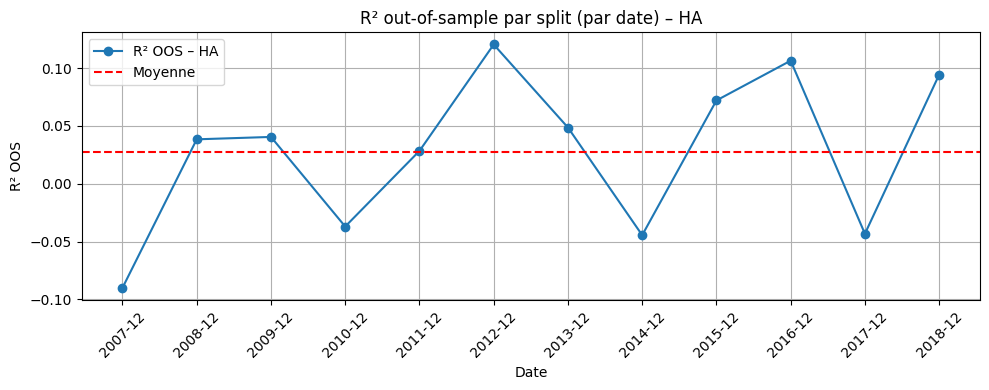

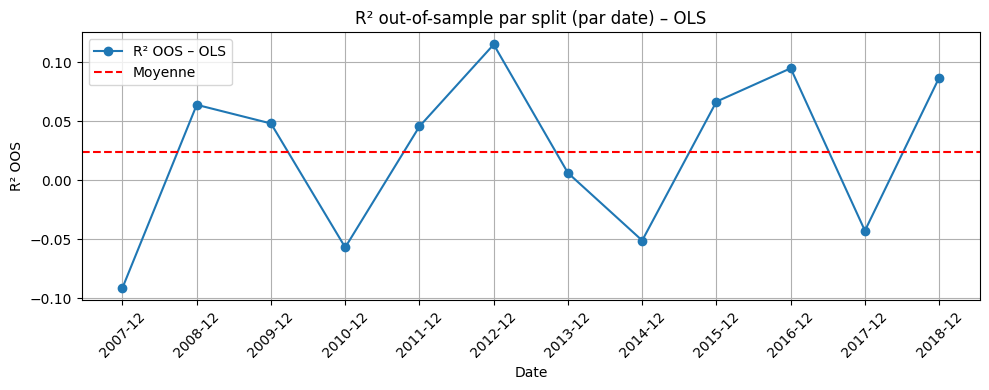

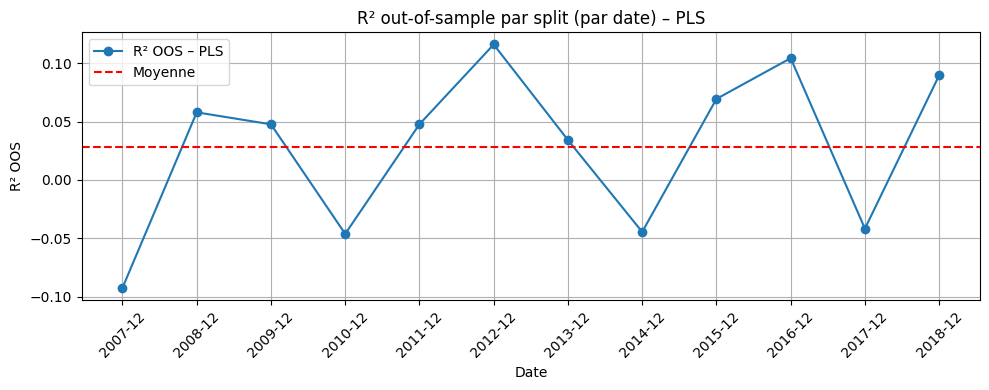

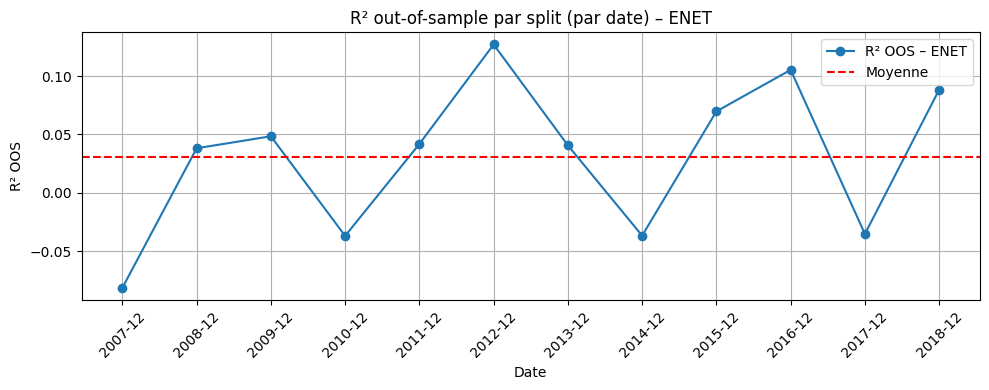

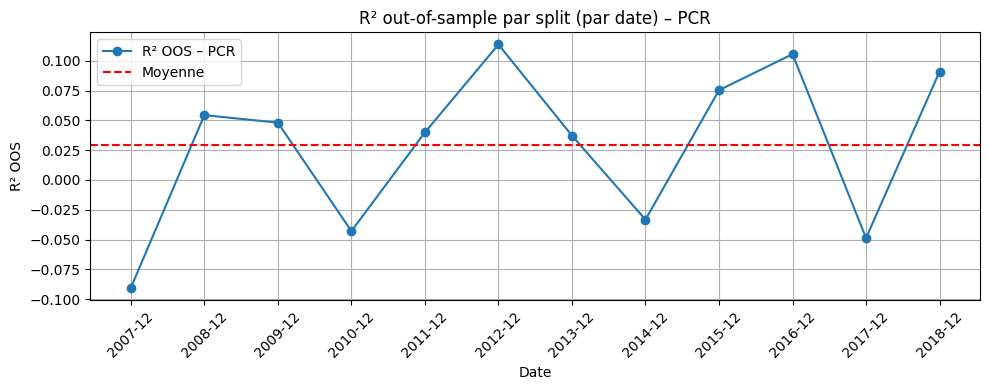

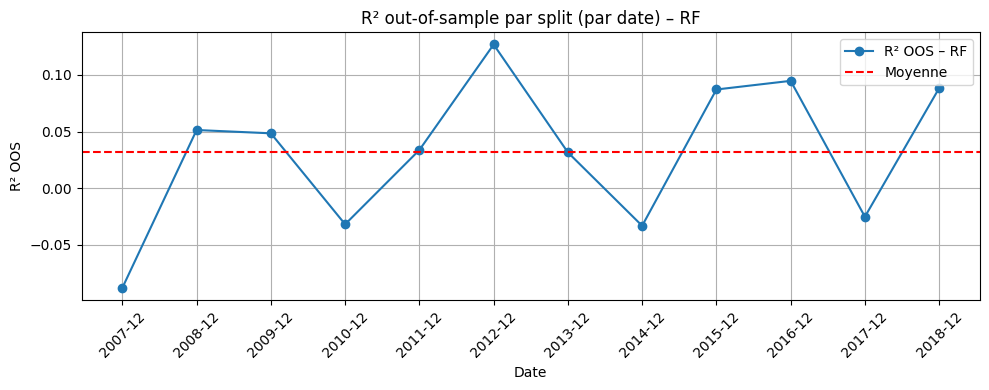

ValueError: x and y must have same first dimension, but have shapes (12,) and (1,)

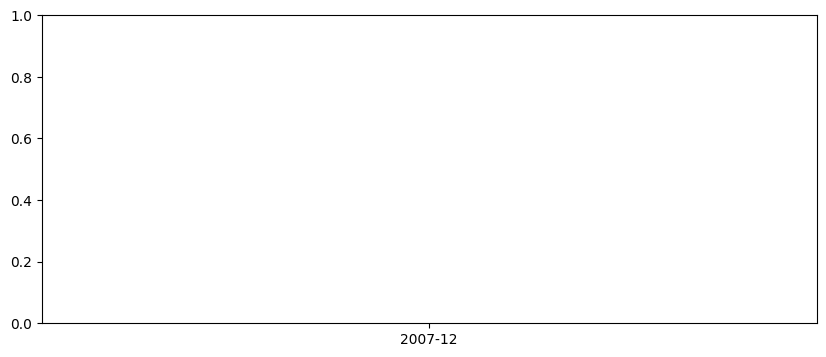

In [156]:
#r2 par split 

#Permet d'extraire la première date de chaque split → on s'en sert dans le graph 

r2_models = {
    "HA": r2_oos_ha,
    "OLS": r2_oos_ols,
    "PLS": r2_oos_pls,
    "ENET" : r2_oos_en,
    "PCR": r2_oos_pcr,
    "RF" : r2_oos_rf, 
    "GBRT": r2_oos_gbrt,
    "XGB": r2_oos_xgb
}

for model_name, r2_oos in r2_models.items():
    plt.figure(figsize=(10, 4))
    plt.plot(first_date_split, r2_oos, marker='o', label=f"R² OOS – {model_name}")
    plt.axhline(np.mean(r2_oos), color='red', linestyle='--', label="Moyenne")
    plt.title(f"R² out-of-sample par split (par date) – {model_name}")
    plt.xlabel("Date")
    plt.ylabel("R² OOS")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [145]:
print(len(r2_oos_ols))  # doit afficher 12


12


In [ ]:
split_dates_dict = {}

# dates_oos est une np.array, donc on les convertit si nécessaire
dates_oos = pd.to_datetime(dates_oos)

for split in np.unique(splits_oos):
    dates_for_split = dates_oos[splits_oos == split]
    date = dates_for_split.min()  # ✅ début du split
    split_dates_dict[split] = date

# Liste ordonnée des dates par numéro de split
split_dates = [split_dates_dict[i] for i in sorted(split_dates_dict.keys())]
print(split_dates)

In [ ]:
models = list(r2_in.keys())
r2_in_values = [r2_in[model] for model in models]
r2_oos_values = [r2_oos[model] for model in models]

x = range(len(models))
bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x, r2_in_values, width=bar_width, label='R² In-sample')
plt.bar([i + bar_width for i in x], r2_oos_values, width=bar_width, label='R² Out-of-sample')

plt.xlabel('Models')
plt.ylabel('R² Score')
plt.title('Comparison of R² In-sample and Out-of-sample per Model')
plt.xticks([i + bar_width/2 for i in x], models, rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
#R2 BENCHMARK

In [ ]:
#DIABOLD TEST 
models = [col for col in df_oos.columns if col.startswith('y_pred_')]
results = []

for i in range(len(models)):
    for j in range(i+1, len(models)):
        model1 = models[i]
        model2 = models[j]

        #calcule mse du modèle 1 et 2 
        e1 = (df_oos['y_true'] - df_oos[model1])**2
        e2 = (df_oos['y_true'] - df_oos[model2])**2
        d = e1 - e2
        d = d.dropna()

        X = np.ones(len(d))  # régression constante
        model = sm.OLS(d, X).fit()
        cov = cov_hac(model, nlags=1)  
        se = np.sqrt(cov[0][0])
        dm_stat = d.mean() / se
        p_value = 2 * (1 - t.cdf(abs(dm_stat), df=len(d) - 1))

        results.append({
            'Model 1': model1,
            'Model 2': model2,
            'DM Stat': dm_stat,
            'P-Value': p_value,
            'Best Model': model2 if dm_stat > 0 else model1
        })


dm_df = pd.DataFrame(results)
#dm_df.sort_values(by="P-Value", ascending=True, inplace=True)
print(dm_df)

In [ ]:
#GRAPH → plot complexités des modèles 

plt.rcParams["text.usetex"] = False #oblige matplot lib à ne pas utiliser latex
plt.rcParams["font.family"] = "Arial" #met arial pcq il me demandait palatino ?


#Récupérer les paramètres de chaque split 
max_depths_rf = [d["max_depth"] for d in best_params_rf]
max_depths_gbrt = [d["max_depth"] for d in best_params_gbrt]
max_depths_xgb = [d["max_depth"] for d in best_params_xgb]

df_best_param = pd.DataFrame({
    "Date": dates_splits,
    "Best_k_pls": best_components_pls,
    "Best_k_pcr": best_components_pcr,
    "non_zero_counts": nonzero_counts_en,
    "max_depths_rf" : max_depths_rf,
    "max_depths_gbrt" : max_depths_gbrt,
    "max_depths_xgb" : max_depths_xgb,
})

#Graphiques : permettent d'analyser la complexité du modèle 
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. PLS
axes[0].plot(df_best_param["Date"], df_best_param["Best_k_pls"], label="PLS", color="royalblue")
axes[0].set_title("Best number of components (PLS)")
axes[0].set_ylabel("k")
axes[0].legend()

# 2. PCR
axes[1].plot(df_best_param["Date"], df_best_param["Best_k_pcr"], label="PCR", color="purple")
axes[1].set_title("Best number of components (PCR)")
axes[1].set_ylabel("k")
axes[1].legend()

# 3. ElasticNet
axes[2].plot(df_best_param["Date"], df_best_param["non_zero_counts"], marker="o", color="seagreen")
axes[2].set_title("Model complexity – ElasticNet")
axes[2].set_ylabel("nonzero counts")
axes[2].set_xlabel("Date")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


#RF, XGBOOST, GBRT
# Position des groupes de barres
x = np.arange(len(df_best_param["Date"]))
width = 0.25

plt.figure(figsize=(14, 5))

plt.bar(x - width, df_best_param["max_depths_rf"], width, label="RF", color="firebrick")
plt.bar(x, df_best_param["max_depths_gbrt"], width, label="GBRT", color="mediumpurple")
plt.bar(x + width, df_best_param["max_depths_xgb"], width, label="XGB", color="darkcyan")

plt.title("Best max_depth per model – RF, GBRT, XGBoost")
plt.xlabel("Date")
plt.ylabel("Max Depth")
plt.xticks(x, df_best_param["Date"], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


METRIQUES : R2 BENCHMARK

In [168]:
df_oos = pd.DataFrame({
    "Date": dates_oos,
    "Ticker": tickers_oos,
    "y_true": y_true,
    "y_pred_ols": y_pred_ols,
    "y_pred_pls": y_pred_pls,
    "y_pred_pcr": y_pred_pcr,
    "y_pred_en": y_pred_en,
    "y_pred_rf": y_pred_rf,
    "y_pred_gbrt": y_pred_gbrt,
    "y_pred_xgb": y_pred_xgb,
    "y_pred_ha": y_pred_ha
})

# Initialisation
r2_vs_ha_results = {}
y_true = df_oos["y_true"]
y_pred_ha = df_oos["y_pred_ha"]

# Boucle sur toutes les colonnes y_pred_*
for col in df_oos.columns:
    if col.startswith("y_pred_"):
        model_name = col.replace("y_pred_", "")
        r2_val = r2_vs_benchmark(y_true, df_oos[col], y_pred_ha)
        r2_vs_ha_results[model_name] = r2_val

# Affichage
for model, r2_val in r2_vs_ha_results.items():
    print(f"{model:<8} R² OOS vs HA : {r2_val:.4f}")


ValueError: All arrays must be of the same length

In [ ]:


print("OLS   : In-sample =", r2_in_ols,  "| OOS =", r2_oos_ols)
print("PLS   : In-sample =", r2_in_pls,  "| OOS =", r2_oos_pls)
print("PCR   : In-sample =", r2_in_pcr,  "| OOS =", r2_oos_pcr)
print("Enet  : In-sample =", r2_in_en,   "| OOS =", r2_oos_en)
print("Rf  : In-sample =", r2_in_rf,   "| OOS =", r2_oos_rf)
print("GBRT  : In-sample =", r2_in_gbrt,   "| OOS =", r2_oos_gbrt)
print("XGB : In-sample =", r2_in_xgb,   "| OOS =", r2_oos_xgb)
print("HA : In-sample =", r2_in_ha,   "| OOS =", r2_oos_ha)


In [ ]:
print(df_oos.head())
df_oos["Split"] = splits_oos


In [ ]:
# Filtrage du DataFrame pour le split 2
df_split2 = df_oos[df_oos["Split"] == 2]

# Extraction des colonnes utiles
y_true_split2 = df_split2["y_true"].to_numpy()
y_benchmark_split2 = df_split2["y_pred_ha"].to_numpy()
y_pred_xgb_split2 = df_split2["y_pred_xgb"].to_numpy()

# Calcul du MSE
mse_ha = mean_squared_error(y_true_split2, y_benchmark_split2)
mse_xgb = mean_squared_error(y_true_split2, y_pred_xgb_split2)

print("MSE HA :", mse_ha)
print("MSE XGB:", mse_xgb)
print("Gain XGB :", mse_ha - mse_xgb)


In [ ]:
print(df_oos.head())

In [ ]:
def compute_mse_diff(actual, y_benchmark, y_pred, k):
    return mean_squared_error(y_benchmark[:k], actual[:k]) - mean_squared_error(y_pred[:k], actual[:k])

df_oos = df_oos.sort_values(by="Date").reset_index(drop=True)

ml_diff_in_cumulative_mse = {}
for col in model_cols:  # ex: ['y_pred_ols', 'y_pred_pls', etc.]
    y_pred = df_oos[col].to_numpy()
    y_benchmark = df_oos["y_pred_ha"].to_numpy()
    y_true = df_oos["y_true"].to_numpy()
    
    diff_mse = [compute_mse_diff(y_true, y_benchmark, y_pred, k) for k in range(1, len(y_true) + 1)]
    ml_diff_in_cumulative_mse[col.replace("y_pred_", "")] = diff_mse

df_cumul_mse = pd.DataFrame(ml_diff_in_cumulative_mse)

In [ ]:
import pandas as pd

df_check = pd.DataFrame({
    "date": dates_oos,  # ou date_array qui correspond à y_true
    "y_true": y_true,
    "y_ha": y_benchmark,
    "y_xgb": y_pred
})

print(df_check.head(20))  # regarde si tu as bien les bonnes valeurs dans le bon ordre


In [ ]:
df_cumul_mse["Date"] = df_oos["Date"].values
df_cumul_mse = df_cumul_mse.set_index("Date")


In [ ]:
print(df_cumul_mse.head())


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for col in df_cum_mse.columns:
    plt.plot(df_cum_mse.index, df_cum_mse[col], label=col)

plt.xlabel("Date")
plt.ylabel("Cumulative MSE Gain vs HA")
plt.title("Cumulative MSE Difference: ML Models vs Historical Average")
plt.axhline(0, color="black", linestyle="--", linewidth=1)  # ligne horizontale à zéro
plt.legend()
plt.ylim(-0.005, 0.005)  # à adapter selon l’amplitude des faibles modèles
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Sélection des colonnes OLS, PLS, PCR
selected_models = ['ols', 'pls', 'pcr']
df_selected = df_cumul_mse[selected_models]

plt.figure(figsize=(12, 6))
for col in df_selected.columns:
    plt.plot(df_selected.index, df_selected[col], label=col)

plt.xlabel("Date" if "Date" in df_cumul_mse.index.name else "Time (index)")
plt.ylabel("Cumulative MSE Gain vs HA")
plt.title("Cumulative MSE Difference: OLS, PLS, PCR vs Historical Average")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
print(df_oos["y_true"].describe())

for col in model_cols:
    print(f"{col}: {df_oos[col].nunique()} valeurs uniques")
print((df_oos["y_pred_ols"] - df_oos["y_pred_ha"]).describe())


In [ ]:
for mois in mois_plats:
    subset = df_oos[df_oos["Date"] == mois][covariates]
    print(f"\n{mois} - % de colonnes à variance nulle : {(subset.var() == 0).mean() * 100:.1f}%")


In [ ]:
r2_in_xgb = r2(y_trainval_true, y_trainval_xgb)
r2_oos_xgb = r2(y_true, y_pred_xgb)
print(r2_oos_xgb)
print(r2_in_xgb)

In [ ]:
print(f"PLS      | R² in-sample : {r2_in_pls:.4f} | R² OOS : {r2_oos_pls:.4f}")
print(f"HA       | R² in-sample : {r2_in_ha:.4f} | R² OOS : {r2_oos_ha:.4f}")
print(f"PCR      | R² in-sample : {r2_in_pcr:.4f} | R² OOS : {r2_oos_pcr:.4f}")
print(f"ElasticNet | R² in-sample : {r2_in_en:.4f} | R² OOS : {r2_oos_en:.4f}")
print(f"RandomForest | R² in-sample : {r2_in_rf:.4f} | R² OOS : {r2_oos_rf:.4f}")
print(f"GBRT     | R² in-sample : {r2_in_gbrt:.4f} | R² OOS : {r2_oos_gbrt:.4f}")




#XGB 

# Affichage



In [ ]:
""""On récupère toutes les données → on va faire les tests directement à la suite du notebook (on reprend les mêmes tests que dans 3_results)"""
#R2 in-sample oos → moyenne
models = ['ha', 'ols', 'pls', 'pcr', 'en', 'rf', 'gbrt', 'xgb']
rows = []
for model in models:
    r2_in = globals()[f"r2_in_{model}"]
    r2_oos = globals()[f"r2_oos_{model}"]
    row = {
            "Model": model.upper(),
            "Split 1 o": r2_oos[0],
            "Split 2 o": r2_oos[1],
            "Split 3 o": r2_oos[2],
            "Split m o": np.mean(r2_oos),
            "Split 1 i": r2_in[0],
            "Split 2 i": r2_in[1],
            "Split 3 i": r2_in[2],
            "Split m i": np.mean(r2_in),
        }
    rows.append(row)

    df_r2_split = pd.DataFrame(rows)

#DF → export (comme ça on a pas à refaire tourner model à chaque fois → trop long)
max_depths_rf = [d["max_depth"] for d in best_params_rf]
max_depths_gbrt = [d["max_depth"] for d in best_params_gbrt]
max_depths_xgb = [d["max_depth"] for d in best_params_xgb]

df_best_param = pd.DataFrame({
    "Date": dates_splits,
    "Best_k_pls": best_components_pls,
    "Best_k_pcr": best_components_pcr,
    "Best lambda": best_lambdas,
    "max_depths_rf" : max_depths_rf,
    "max_depths_gbrt" : max_depths_gbrt,
    "max_depths_xgb" : max_depths_xgb
})



In [ ]:
print(len(dates_oos))
print(len(y_true))
print(len(y_pred_ols))

In [ ]:
df_in = pd.DataFrame({
    "Date": dates_in,
    "Ticker": tickers_in,
    "y_trainval_true": y_trainval_true,
    "y_trainval_pred_ha": y_trainval_pred_ha,
    "y_trainval_ols": y_trainval_ols,
    "y_trainval_pls": y_trainval_pls,
    "y_trainval_pcr": y_trainval_pcr,
    "y_trainval_en": y_trainval_en,
    "y_trainval_rf": y_trainval_rf,
    "y_trainval_gbrt": y_trainval_gbrt,
    "y_trainval_xgb": y_trainval_xgb
})

df_oos = pd.DataFrame({
    "Date": dates_oos,
    "Ticker": tickers_oos,
    "y_true": y_true,
    "y_pred_ols": y_pred_ols,
    "y_pred_pls": y_pred_pls,
    "y_pred_pcr": y_pred_pcr,
    "y_pred_en": y_pred_en,
    "y_pred_rf": y_pred_rf,
    "y_pred_gbrt": y_pred_gbrt,
    "y_pred_xgb": y_pred_xgb,
    "y_pred_ha": y_pred_ha
})



In [ ]:
"""IMPORT DES DATAFRAMES DETAIL : 
df_best_param : pas utilité
df_in : prédictions in-sample
df_oos : prédictions out-of-sample 
df_r2_split_oos : r2 de chaque split """

df_best_param = pd.read_excel("df_best_param.xlsx")
df_in = pd.read_excel("df_in.xlsx")
df_oos = pd.read_excel("df_oos.xlsx")
df_r2_split = pd.read_excel("df_r2_split.xlsx")

In [ ]:
# GBRT
r2_in_gbrt = r2(y_trainval_true, y_trainval_gbrt)
r2_oos_gbrt = r2(y_true, y_pred_gbrt)

# XGB
r2_in_xgb = r2(y_trainval_true, y_trainval_xgb)
r2_oos_xgb = r2(y_true, y_pred_xgb)

print("GBRT  : In-sample =", r2_in_gbrt, "| OOS =", r2_oos_gbrt)
print("XGB   : In-sample =", r2_in_xgb,  "| OOS =", r2_oos_xgb)